In [1]:
#pip install -r requirements.txt

In [8]:
import evaluate

seqeval = evaluate.load("seqeval")

In [9]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("FacebookAI/roberta-base",
                                          add_prefix_space=True,
                                          max_length=512)

In [12]:
id2label = {
    0: "O",
    1: "B-EquipmentName",
    2: "I-EquipmentName",
    3: "B-DeviceProperties",
    4: "I-DeviceProperties",
    5: "B-FaultCode",
    6: "I-FaultCode",
    7: "B-FaultType",
    8: "I-FaultType",
    9: "B-MaintenanceMethod",
    10: "I-MaintenanceMethod",
    11: "B-VehicleComponentLocation",
    12: "I-VehicleComponentLocation",
    13: "B-MeasurementValue",
    14: "I-MeasurementValue",
    15: "B-VehicleMakeModel",
    16: "I-VehicleMakeModel",
    17: "B-TimeDuration",
    18: "I-TimeDuration",
    19: "B-CustomerReportedSymptom",
    20: "I-CustomerReportedSymptom"
}

label2id = {v: k for k, v in id2label.items()}

In [14]:
def read_conll(file_path):
    with open(file_path, 'r', encoding='utf-8') as file:
        lines = file.readlines()

    sentences = []
    sentence = []
    for line in lines:
        if line.strip() == '' or line.startswith('-DOCSTART-'):
            if sentence:
                sentences.append(sentence)
                sentence = []
        else:
            parts = line.strip().split()
            if len(parts) >= 2:
                word = parts[0]
                tag = parts[-1]  # Assume last column is the tag
                sentence.append((word, tag))
    if sentence:
        sentences.append(sentence)
    return sentences

def convert_to_desired_format(sentences, label2id):
    updated_dataset = []
    for idx, sentence in enumerate(sentences):
        tokens = [token for token, tag in sentence]
        # Convert string tags to their corresponding integer IDs
        ner_tags = [label2id.get(tag, 0) for _, tag in sentence]  # default to 'O' (0) if tag not found

        sentence_data = {
            'id': str(idx),
            'tokens': tokens,
            'ner_tags': ner_tags
        }
        updated_dataset.append(sentence_data)
    return updated_dataset

# Replace 'path_to_conll_dataset' with the path to your CoNLL dataset
conll_sentences = read_conll('synthetic_train_v1.conll')
conll_test_sentences = read_conll('synthetic_test_v1.conll')
updated_train_dataset = convert_to_desired_format(conll_sentences,label2id)
updated_test_dataset = convert_to_desired_format(conll_test_sentences,label2id)


# Now, updated_dataset contains your data in the desired format

In [16]:
def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(examples["tokens"], truncation=True, is_split_into_words=True)

    labels = []
    for i, label in enumerate(examples[f"ner_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)  # Map tokens to their respective word.
        previous_word_idx = None
        label_ids = []
        for word_idx in word_ids:  # Set the special tokens to -100.
            if word_idx is None:
                label_ids.append(-100)
            elif word_idx != previous_word_idx:  # Only label the first token of a given word.
                label_ids.append(label[word_idx])
            else:
                label_ids.append(-100)
            previous_word_idx = word_idx
        labels.append(label_ids)

    tokenized_inputs["labels"] = labels
    return tokenized_inputs


In [18]:
from datasets import Dataset

data_train = updated_train_dataset
data_test = updated_test_dataset

train_dict = {key: [dic[key] for dic in data_train] for key in data_train[0]}
test_dict = {key: [dic[key] for dic in data_test] for key in data_test[0]}


hf_train = Dataset.from_dict(train_dict)
hf_test = Dataset.from_dict(test_dict)


hf_test

Dataset({
    features: ['id', 'tokens', 'ner_tags'],
    num_rows: 2000
})

In [20]:
tokenized_train = hf_train.map(tokenize_and_align_labels, batched=True)
tokenized_test = hf_test.map(tokenize_and_align_labels, batched=True)

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [22]:
tokenized_test


Dataset({
    features: ['id', 'tokens', 'ner_tags', 'input_ids', 'attention_mask', 'labels'],
    num_rows: 2000
})

In [24]:
from transformers import DataCollatorForTokenClassification

data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

In [26]:
def pretty_print_metrics(metrics):
    # Header
    print("{:<20} {:<10} {:<10} {:<10}".format('Entity Type', 'TP', 'FP', 'FN'))
    print('-' * 50)

    # Data rows
    for entity, counts in metrics.items():
        print("{:<20} {:<10} {:<10} {:<10}".format(entity, counts['TP'], counts['FP'], counts['FN']))

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(cm, class_labels):
    """
    Plots a normalized confusion matrix as percentages using Seaborn's heatmap().
    
    Args:
    cm (numpy.ndarray): The confusion matrix to plot.
    class_labels (list): List of class labels corresponding to the matrix axes.
    """
    # Convert the normalized confusion matrix to percentages
    cm_percentages = np.round(cm * 100, 2)  # Convert to percentage and round off
    
    plt.figure(figsize=(40, 30))  # Adjust the size as needed
    sns.heatmap(cm_percentages, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels,
                cbar_kws={'label': 'Percentage (%)'})
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix (Percentages)')
    plt.show()

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [30]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report


label_list = list(label2id.keys())

# labels = [label_list[i] for i in example[f"ner_tags"]]


# def compute_metrics(p):
#     predictions, labels = p
#     predictions = np.argmax(predictions, axis=2)

#     true_predictions = [
#         [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
#         for prediction, label in zip(predictions, labels)
#     ]
#     true_labels = [
#         [label_list[l] for (p, l) in zip(prediction, label) if l != -100]
#         for prediction, label in zip(predictions, labels)
#     ]

#     results = seqeval.compute(predictions=true_predictions, references=true_labels)
#     return {
#         "precision": results["overall_precision"],
#         "recall": results["overall_recall"],
#         "f1": results["overall_f1"],
#         "accuracy": results["overall_accuracy"],
#     }

from seqeval.metrics import classification_report

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    # Process predictions and labels
    true_predictions = [
        [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [label_list[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    # Flatten the lists for confusion matrix calculation
    flat_true_predictions = [item for sublist in true_predictions for item in sublist]
    flat_true_labels = [item for sublist in true_labels for item in sublist]
     

    cm = confusion_matrix(flat_true_labels, flat_true_predictions, labels=label_list,normalize='true')
    plot_confusion_matrix(cm, label_list)


    # Calculat overall metrics as well as label report for indvidual classes
    overall_results = seqeval.compute(predictions=true_predictions, references=true_labels)
    label_report = classification_report(true_labels, true_predictions)
    

    # Calculate TP, FP, FN for each class
    detailed_metrics = {}
    for label in label_list:
        tp = sum(t == p == label for true_pred, true_lab in zip(true_predictions, true_labels) for t, p in zip(true_pred, true_lab))
        fp = sum(t != label and p == label for true_pred, true_lab in zip(true_predictions, true_labels) for t, p in zip(true_pred, true_lab))
        fn = sum(t == label and p != label for true_pred, true_lab in zip(true_predictions, true_labels) for t, p in zip(true_pred, true_lab))

        detailed_metrics[label] = {"TP": tp, "FP": fp, "FN": fn}

    
    print(label_report)
    pretty_print_metrics(detailed_metrics)
    
    return {
        "precision": overall_results["overall_precision"],
        "recall": overall_results["overall_recall"],
        "f1": overall_results["overall_f1"],
        "accuracy": overall_results["overall_accuracy"],
        "label_report": label_report
    }

In [56]:
from transformers import AutoModelForTokenClassification, TrainingArguments, Trainer
model = AutoModelForTokenClassification.from_pretrained(
    "FacebookAI/roberta-base", num_labels=21, id2label=id2label, label2id=label2id,ignore_mismatched_sizes=True
)

Some weights of RobertaForTokenClassification were not initialized from the model checkpoint at FacebookAI/roberta-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [58]:
from datetime import datetime

start_time = datetime.now().isoformat()
model_name = f"roberta-base-automotive-{start_time}"

In [60]:
model_directory = f"checkpoints/{model_name}"


In [62]:
#import torch
#torch.cuda.empty_cache()


In [64]:
#pip install accelerate==0.21.0

/opt/anaconda3/lib/python3.12/site-packages/transformers/training_args.py:1594: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/var/folders/hx/q1s4c6ws0dn84_dnnjvs7skc0000gp/T/ipykernel_22345/88259817.py:16: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy,Label Report
1,0.001900,0.000271,0.999900,0.999950,0.999925,0.999979,precision recall f1-score support CustomerReportedSymptom 1.00 1.00 1.00 2000 DeviceProperties 1.00 1.00 1.00 2000 EquipmentName 1.00 1.00 1.00 1996 FaultCode 1.00 1.00 1.00 2000 FaultType 1.00 1.00 1.00 2000 MaintenanceMethod 1.00 1.00 1.00 2000 MeasurementValue 1.00 1.00 1.00 2000 TimeDuration 1.00 1.00 1.00 2000 VehicleComponentLocation 1.00 1.00 1.00 2000 VehicleMakeModel 1.00 1.00 1.00 2000 micro avg 1.00 1.00 1.00 19996 macro avg 1.00 1.00 1.00 19996 weighted avg 1.00 1.00 1.00 19996
2,0.000500,0.000068,1.000000,1.000000,1.000000,1.000000,precision recall f1-score support CustomerReportedSymptom 1.00 1.00 1.00 2000 DeviceProperties 1.00 1.00 1.00 2000 EquipmentName 1.00 1.00 1.00 1996 FaultCode 1.00 1.00 1.00 2000 FaultType 1.00 1.00 1.00 2000 MaintenanceMethod 1.00 1.00 1.00 2000 MeasurementValue 1.00 1.00 1.00 2000 TimeDuration 1.00 1.00 1.00 2000 VehicleComponentLocation 1.00 1.00 1.00 2000 VehicleMakeModel 1.00 1.00 1.00 2000 micro avg 1.00 1.00 1.00 19996 macro avg 1.00 1.00 1.00 19996 weighted avg 1.00 1.00 1.00 19996
3,0.000600,0.000048,1.000000,1.000000,1.000000,1.000000,precision recall f1-score support CustomerReportedSymptom 1.00 1.00 1.00 2000 DeviceProperties 1.00 1.00 1.00 2000 EquipmentName 1.00 1.00 1.00 1996 FaultCode 1.00 1.00 1.00 2000 FaultType 1.00 1.00 1.00 2000 MaintenanceMethod 1.00 1.00 1.00 2000 MeasurementValue 1.00 1.00 1.00 2000 TimeDuration 1.00 1.00 1.00 2000 VehicleComponentLocation 1.00 1.00 1.00 2000 VehicleMakeModel 1.00 1.00 1.00 2000 micro avg 1.00 1.00 1.00 19996 macro avg 1.00 1.00 1.00 19996 weighted avg 1.00 1.00 1.00 19996
4,0.000200,0.000036,1.000000,1.000000,1.000000,1.000000,precision recall f1-score support CustomerReportedSymptom 1.00 1.00 1.00 2000 DeviceProperties 1.00 1.00 1.00 2000 EquipmentName 1.00 1.00 1.00 1996 FaultCode 1.00 1.00 1.00 2000 FaultType 1.00 1.00 1.00 2000 MaintenanceMethod 1.00 1.00 1.00 2000 MeasurementValue 1.00 1.00 1.00 2000 TimeDuration 1.00 1.00 1.00 2000 VehicleComponentLocation 1.00 1.00 1.00 2000 VehicleMakeModel 1.00 1.00 1.00 2000 micro avg 1.00 1.00 1.00 19996 macro avg 1.00 1.00 1.00 19996 weighted avg 1.00 1.00 1.00 19996
5,0.000200,0.000031,1.000000,1.000000,1.000000,1.000000,precision recall f1-score support CustomerReportedSymptom 1.00 1.00 1.00 2000 DeviceProperties 1.00 1.00 1.00 2000 EquipmentName 1.00 1.00 1.00 1996 FaultCode 1.00 1.00 1.00 2000 FaultType 1.00 1.00 1.00 2000 MaintenanceMethod 1.00 1.00 1.00 2000 MeasurementValue 1.00 1.00 1.00 2000 TimeDuration 1.00 1.00 1.00 2000 VehicleComponentLocation 1.00 1.00 1.00 2000 VehicleMakeModel 1.00 1.00 1.00 2000 micro avg 1.00 1.00 1.00 19996 macro avg 1.00 1.00 1.00 19996 weighted avg 1.00 1.00 1.00 19996


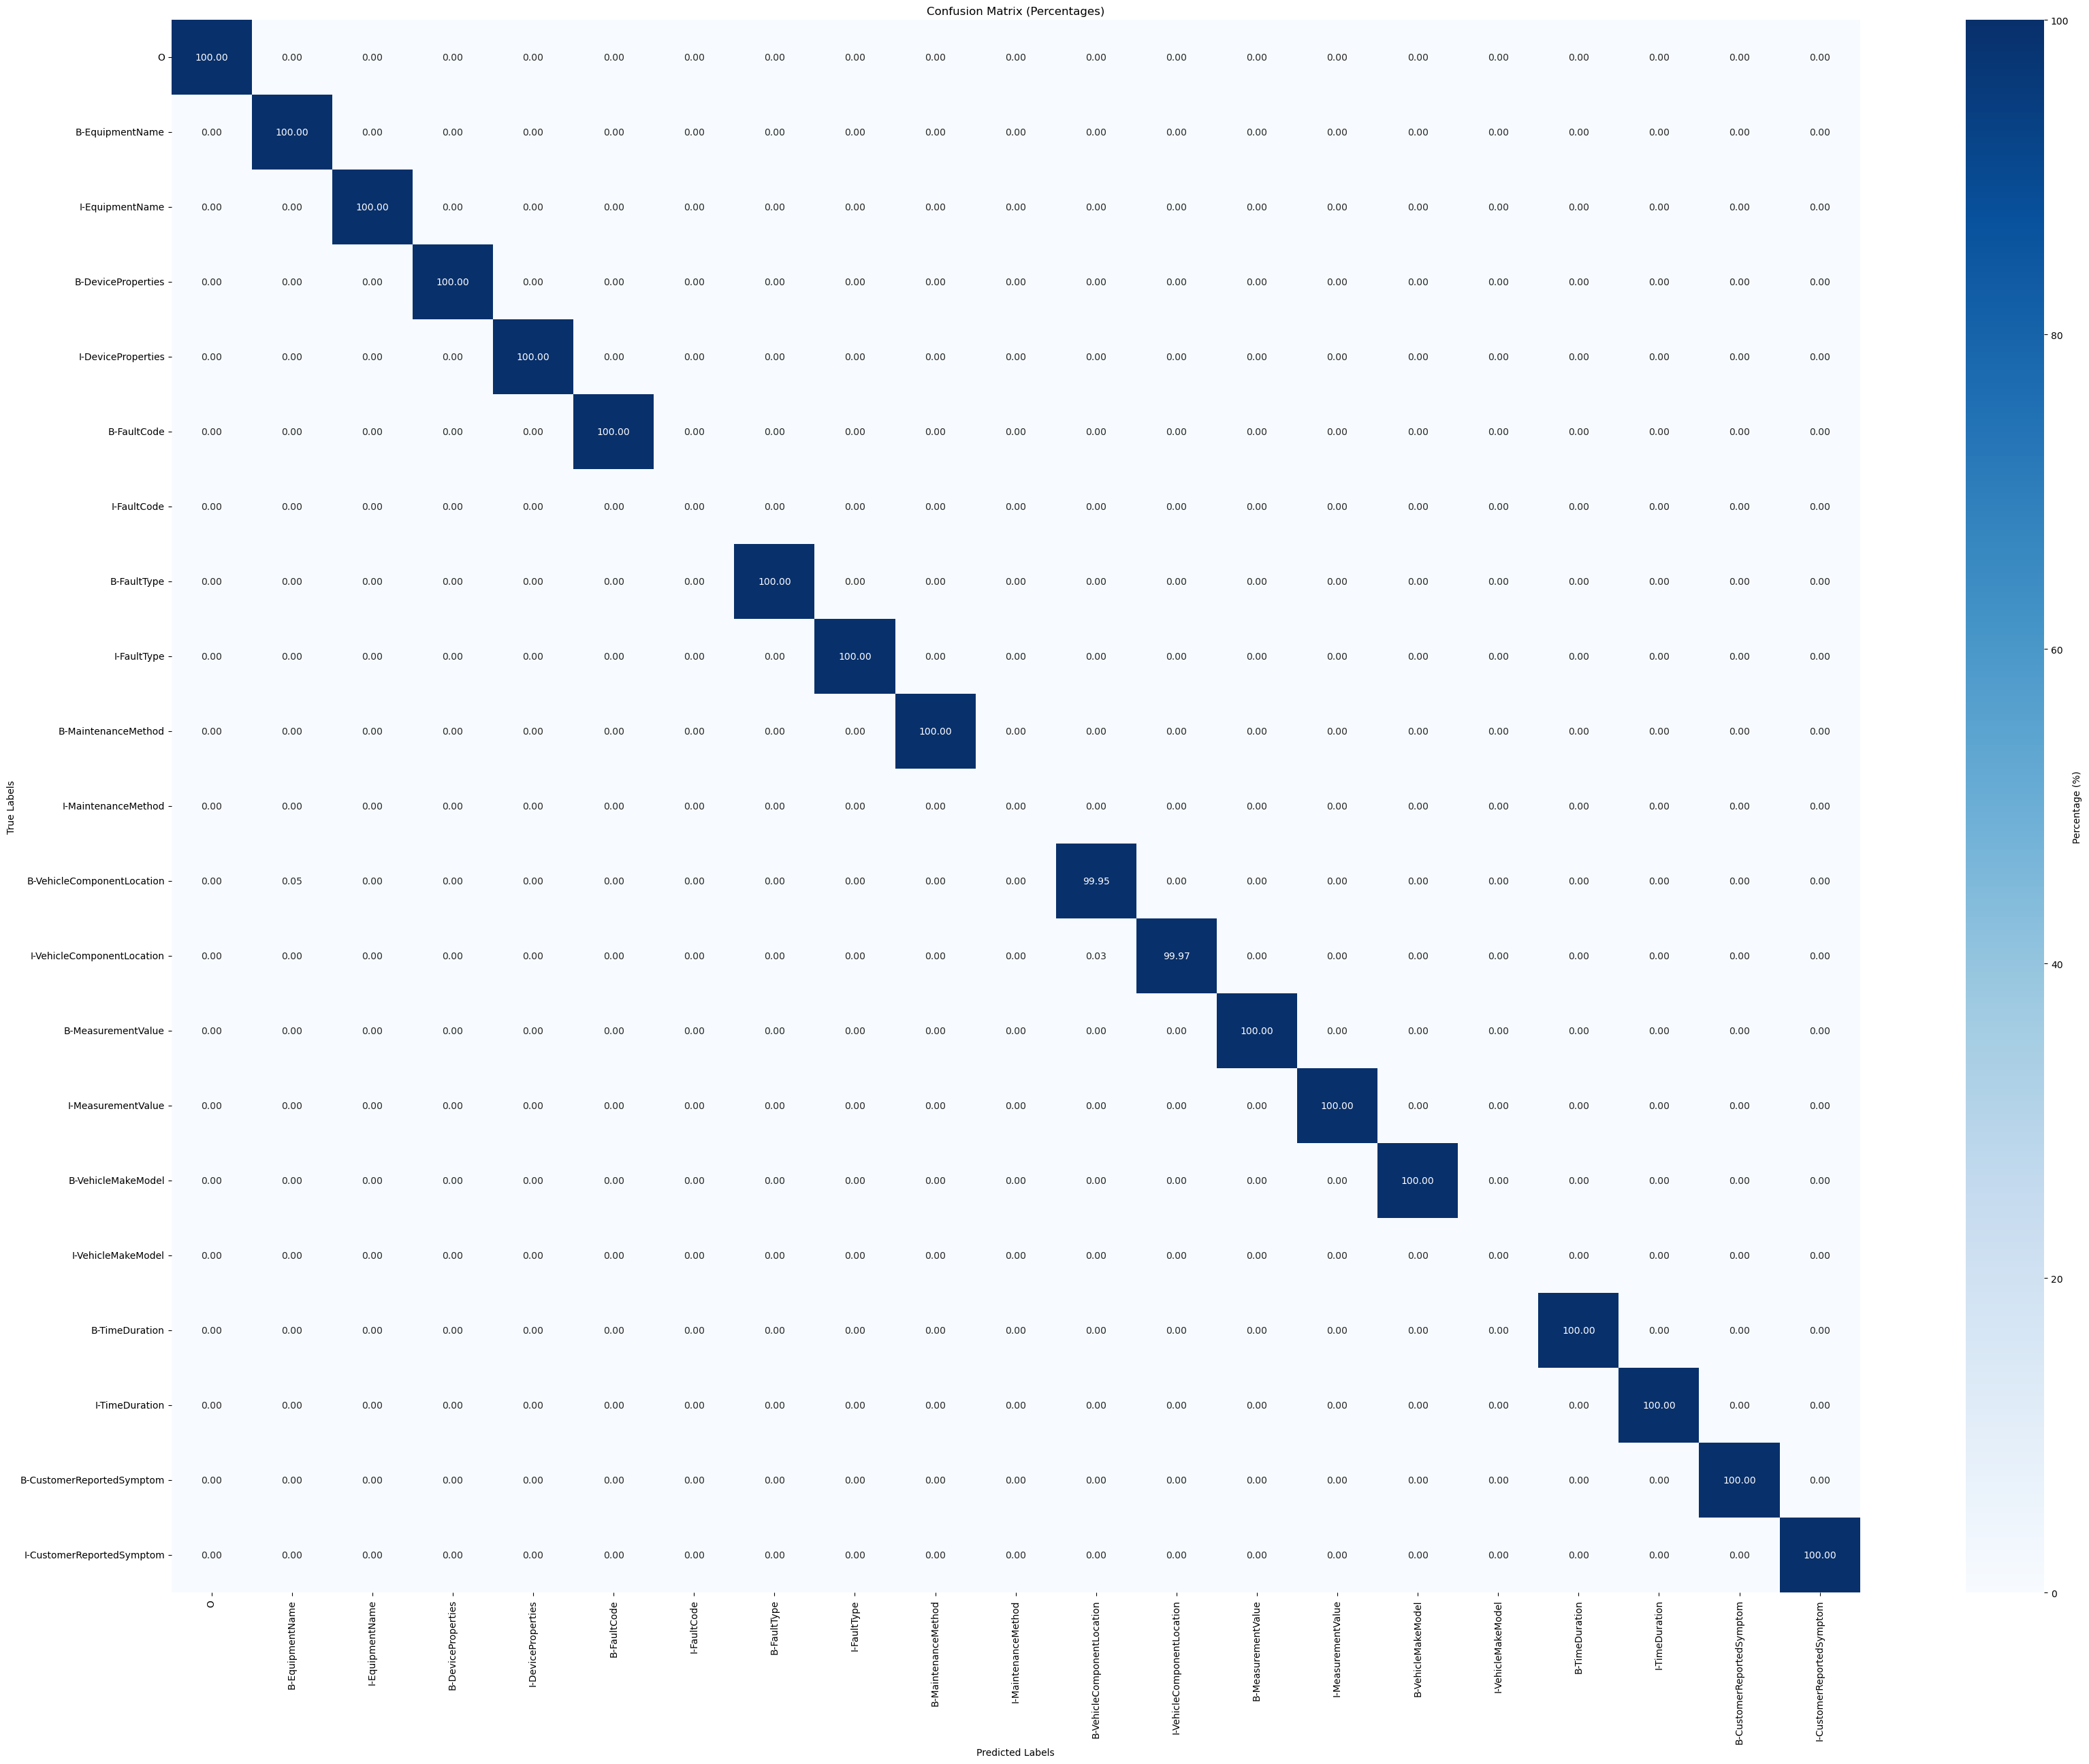

                          precision    recall  f1-score   support

 CustomerReportedSymptom       1.00      1.00      1.00      2000
        DeviceProperties       1.00      1.00      1.00      2000
           EquipmentName       1.00      1.00      1.00      1996
               FaultCode       1.00      1.00      1.00      2000
               FaultType       1.00      1.00      1.00      2000
       MaintenanceMethod       1.00      1.00      1.00      2000
        MeasurementValue       1.00      1.00      1.00      2000
            TimeDuration       1.00      1.00      1.00      2000
VehicleComponentLocation       1.00      1.00      1.00      2000
        VehicleMakeModel       1.00      1.00      1.00      2000

               micro avg       1.00      1.00      1.00     19996
               macro avg       1.00      1.00      1.00     19996
            weighted avg       1.00      1.00      1.00     19996

Entity Type          TP         FP         FN        
-------------------

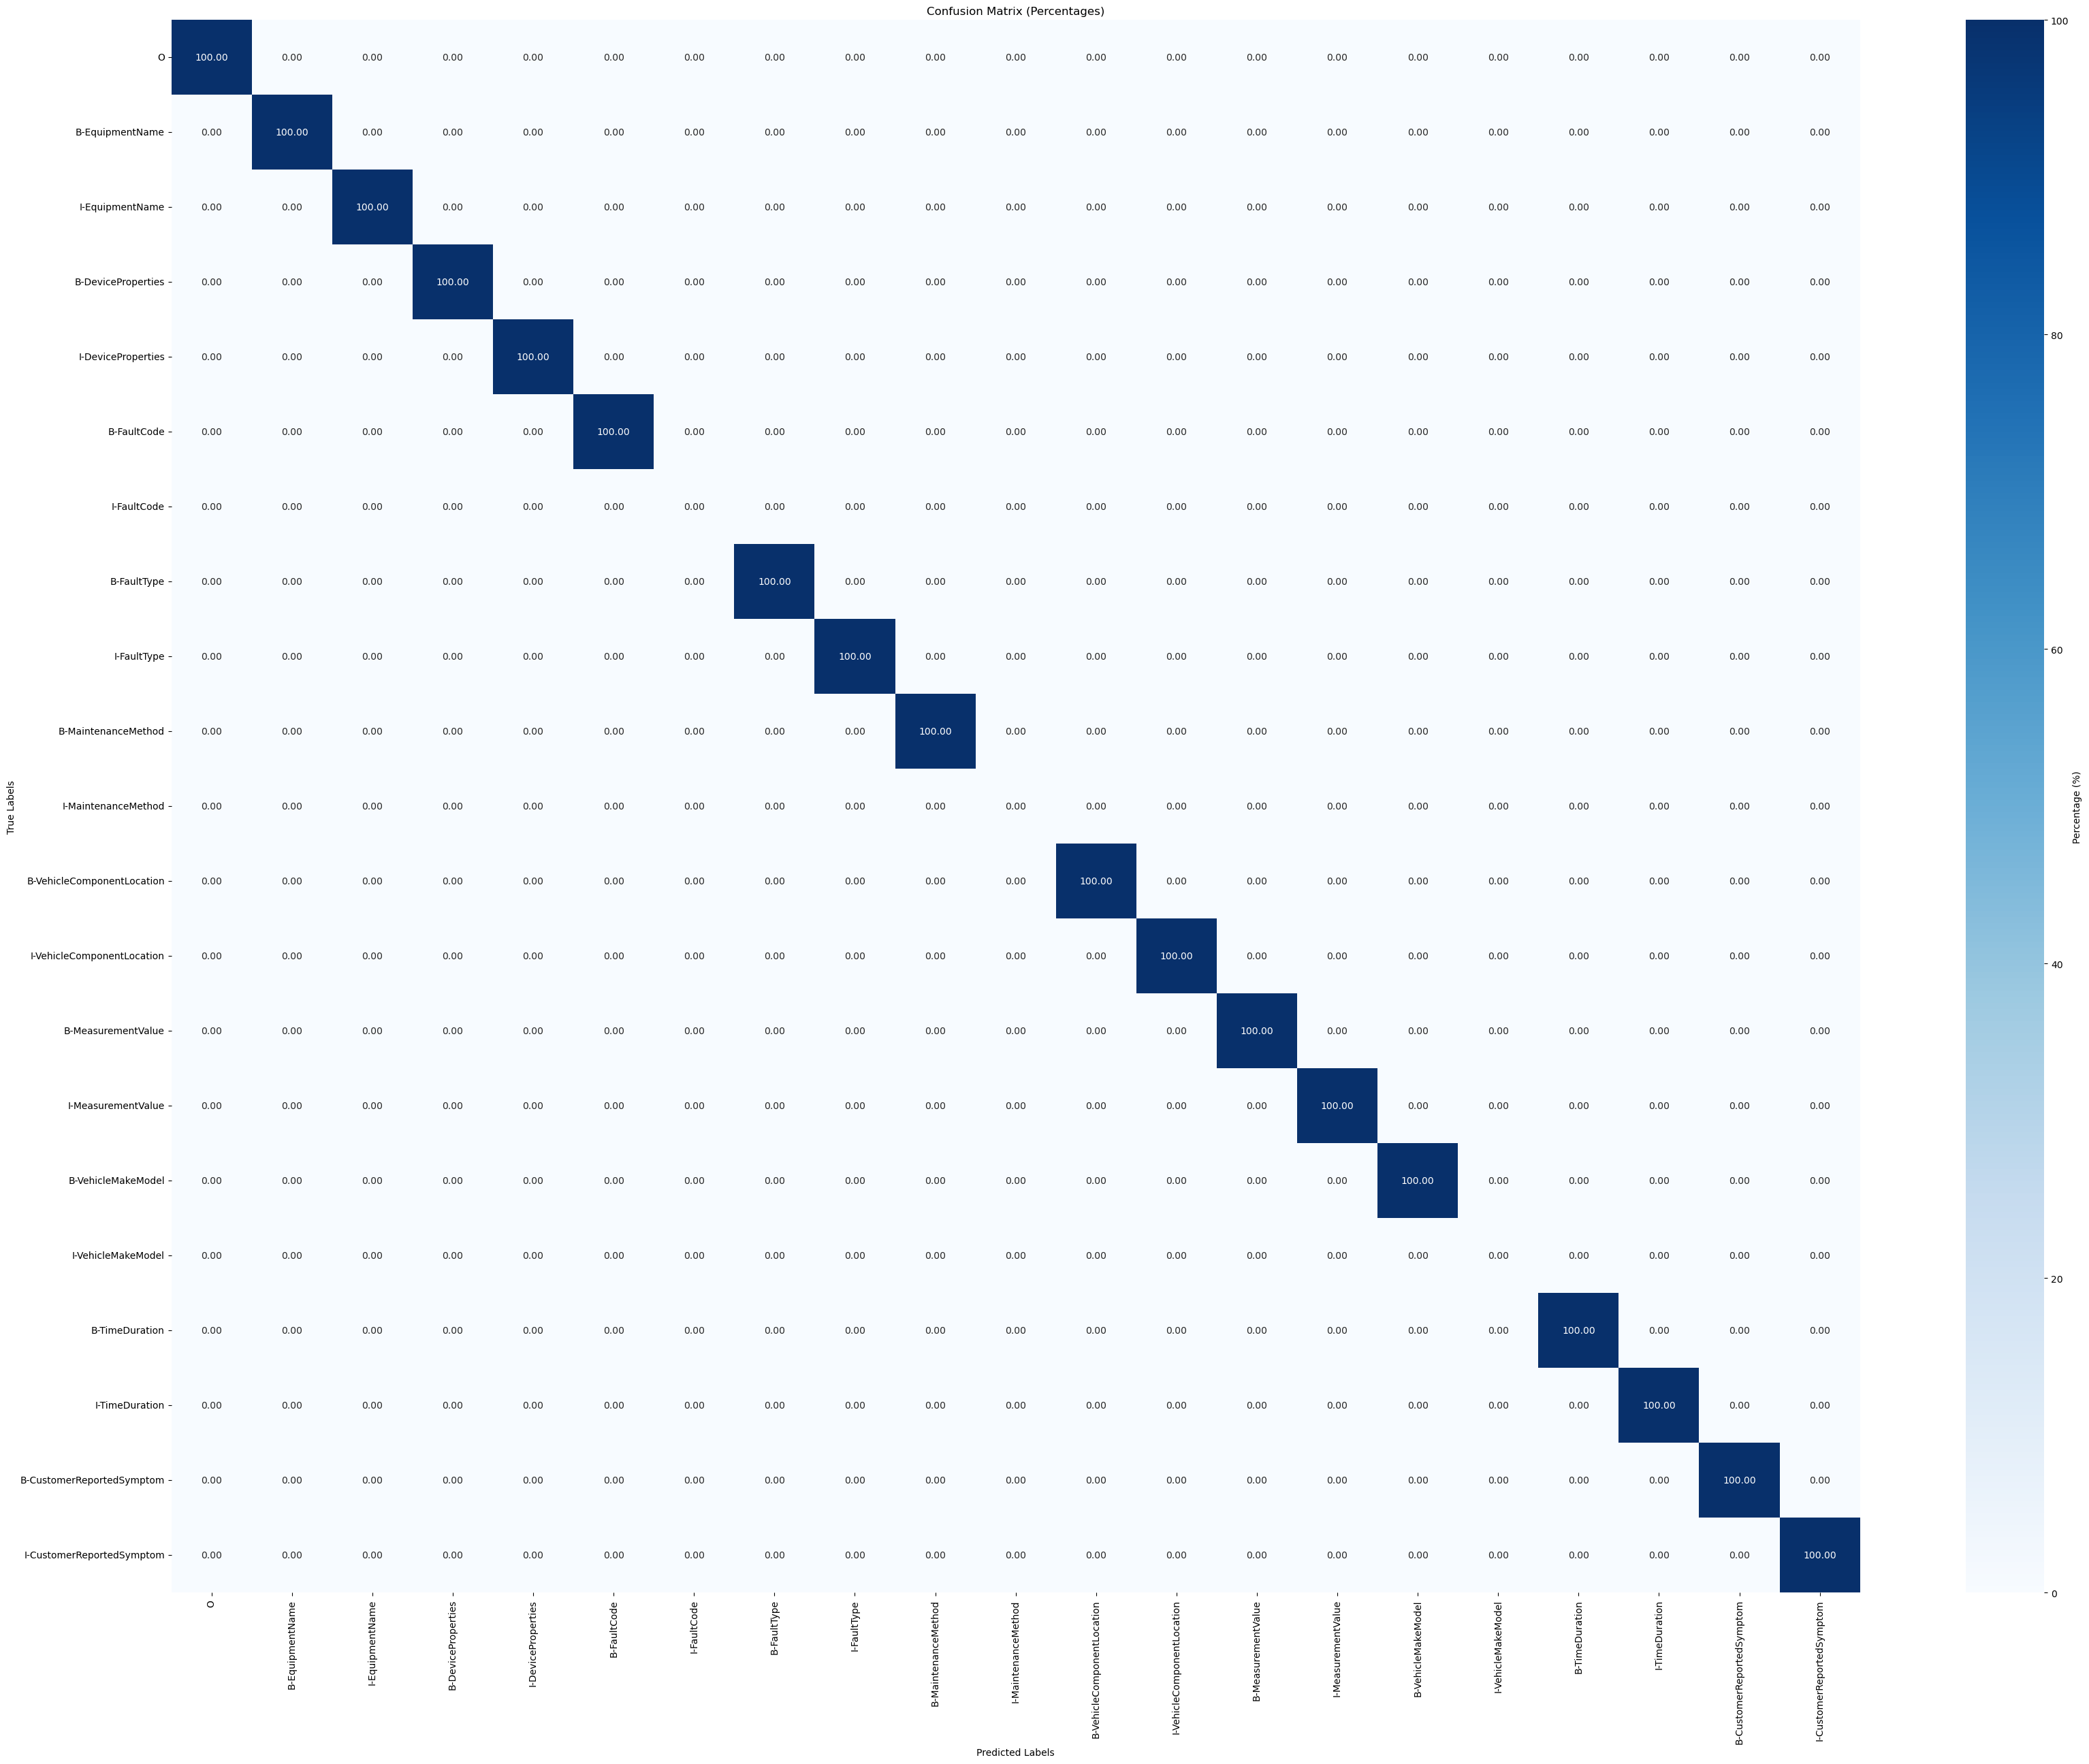

                          precision    recall  f1-score   support

 CustomerReportedSymptom       1.00      1.00      1.00      2000
        DeviceProperties       1.00      1.00      1.00      2000
           EquipmentName       1.00      1.00      1.00      1996
               FaultCode       1.00      1.00      1.00      2000
               FaultType       1.00      1.00      1.00      2000
       MaintenanceMethod       1.00      1.00      1.00      2000
        MeasurementValue       1.00      1.00      1.00      2000
            TimeDuration       1.00      1.00      1.00      2000
VehicleComponentLocation       1.00      1.00      1.00      2000
        VehicleMakeModel       1.00      1.00      1.00      2000

               micro avg       1.00      1.00      1.00     19996
               macro avg       1.00      1.00      1.00     19996
            weighted avg       1.00      1.00      1.00     19996

Entity Type          TP         FP         FN        
-------------------

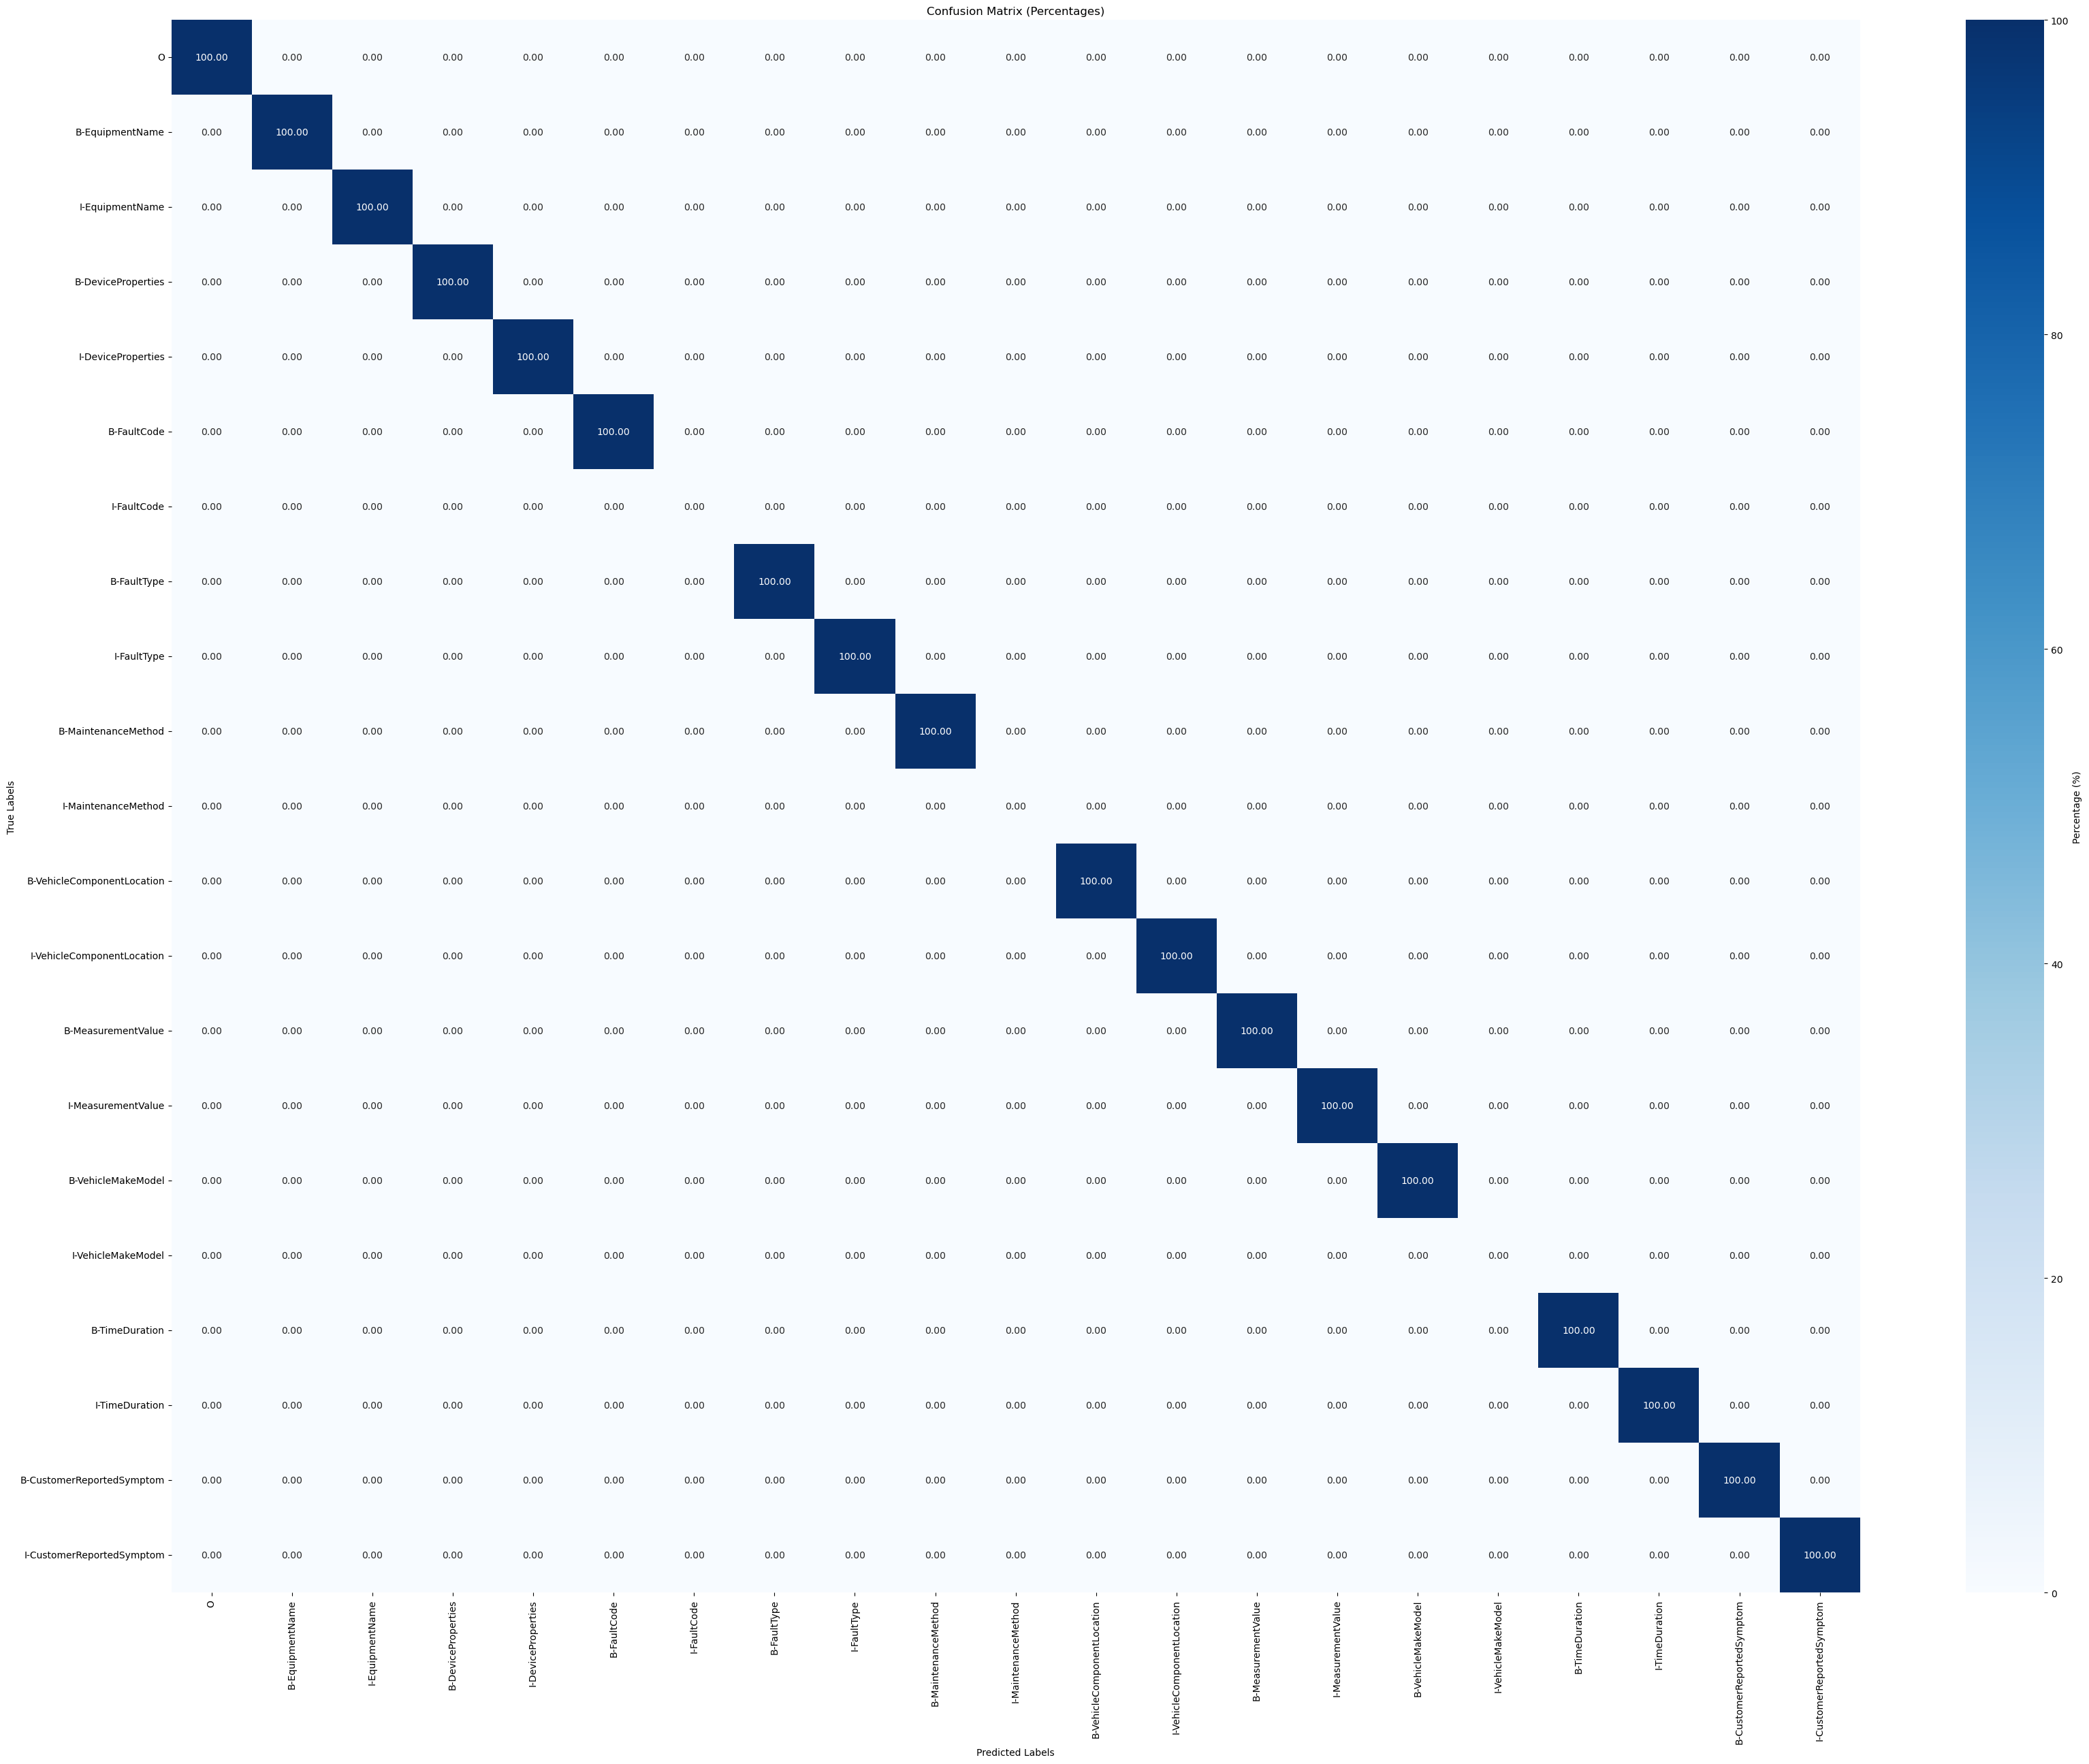

                          precision    recall  f1-score   support

 CustomerReportedSymptom       1.00      1.00      1.00      2000
        DeviceProperties       1.00      1.00      1.00      2000
           EquipmentName       1.00      1.00      1.00      1996
               FaultCode       1.00      1.00      1.00      2000
               FaultType       1.00      1.00      1.00      2000
       MaintenanceMethod       1.00      1.00      1.00      2000
        MeasurementValue       1.00      1.00      1.00      2000
            TimeDuration       1.00      1.00      1.00      2000
VehicleComponentLocation       1.00      1.00      1.00      2000
        VehicleMakeModel       1.00      1.00      1.00      2000

               micro avg       1.00      1.00      1.00     19996
               macro avg       1.00      1.00      1.00     19996
            weighted avg       1.00      1.00      1.00     19996

Entity Type          TP         FP         FN        
-------------------

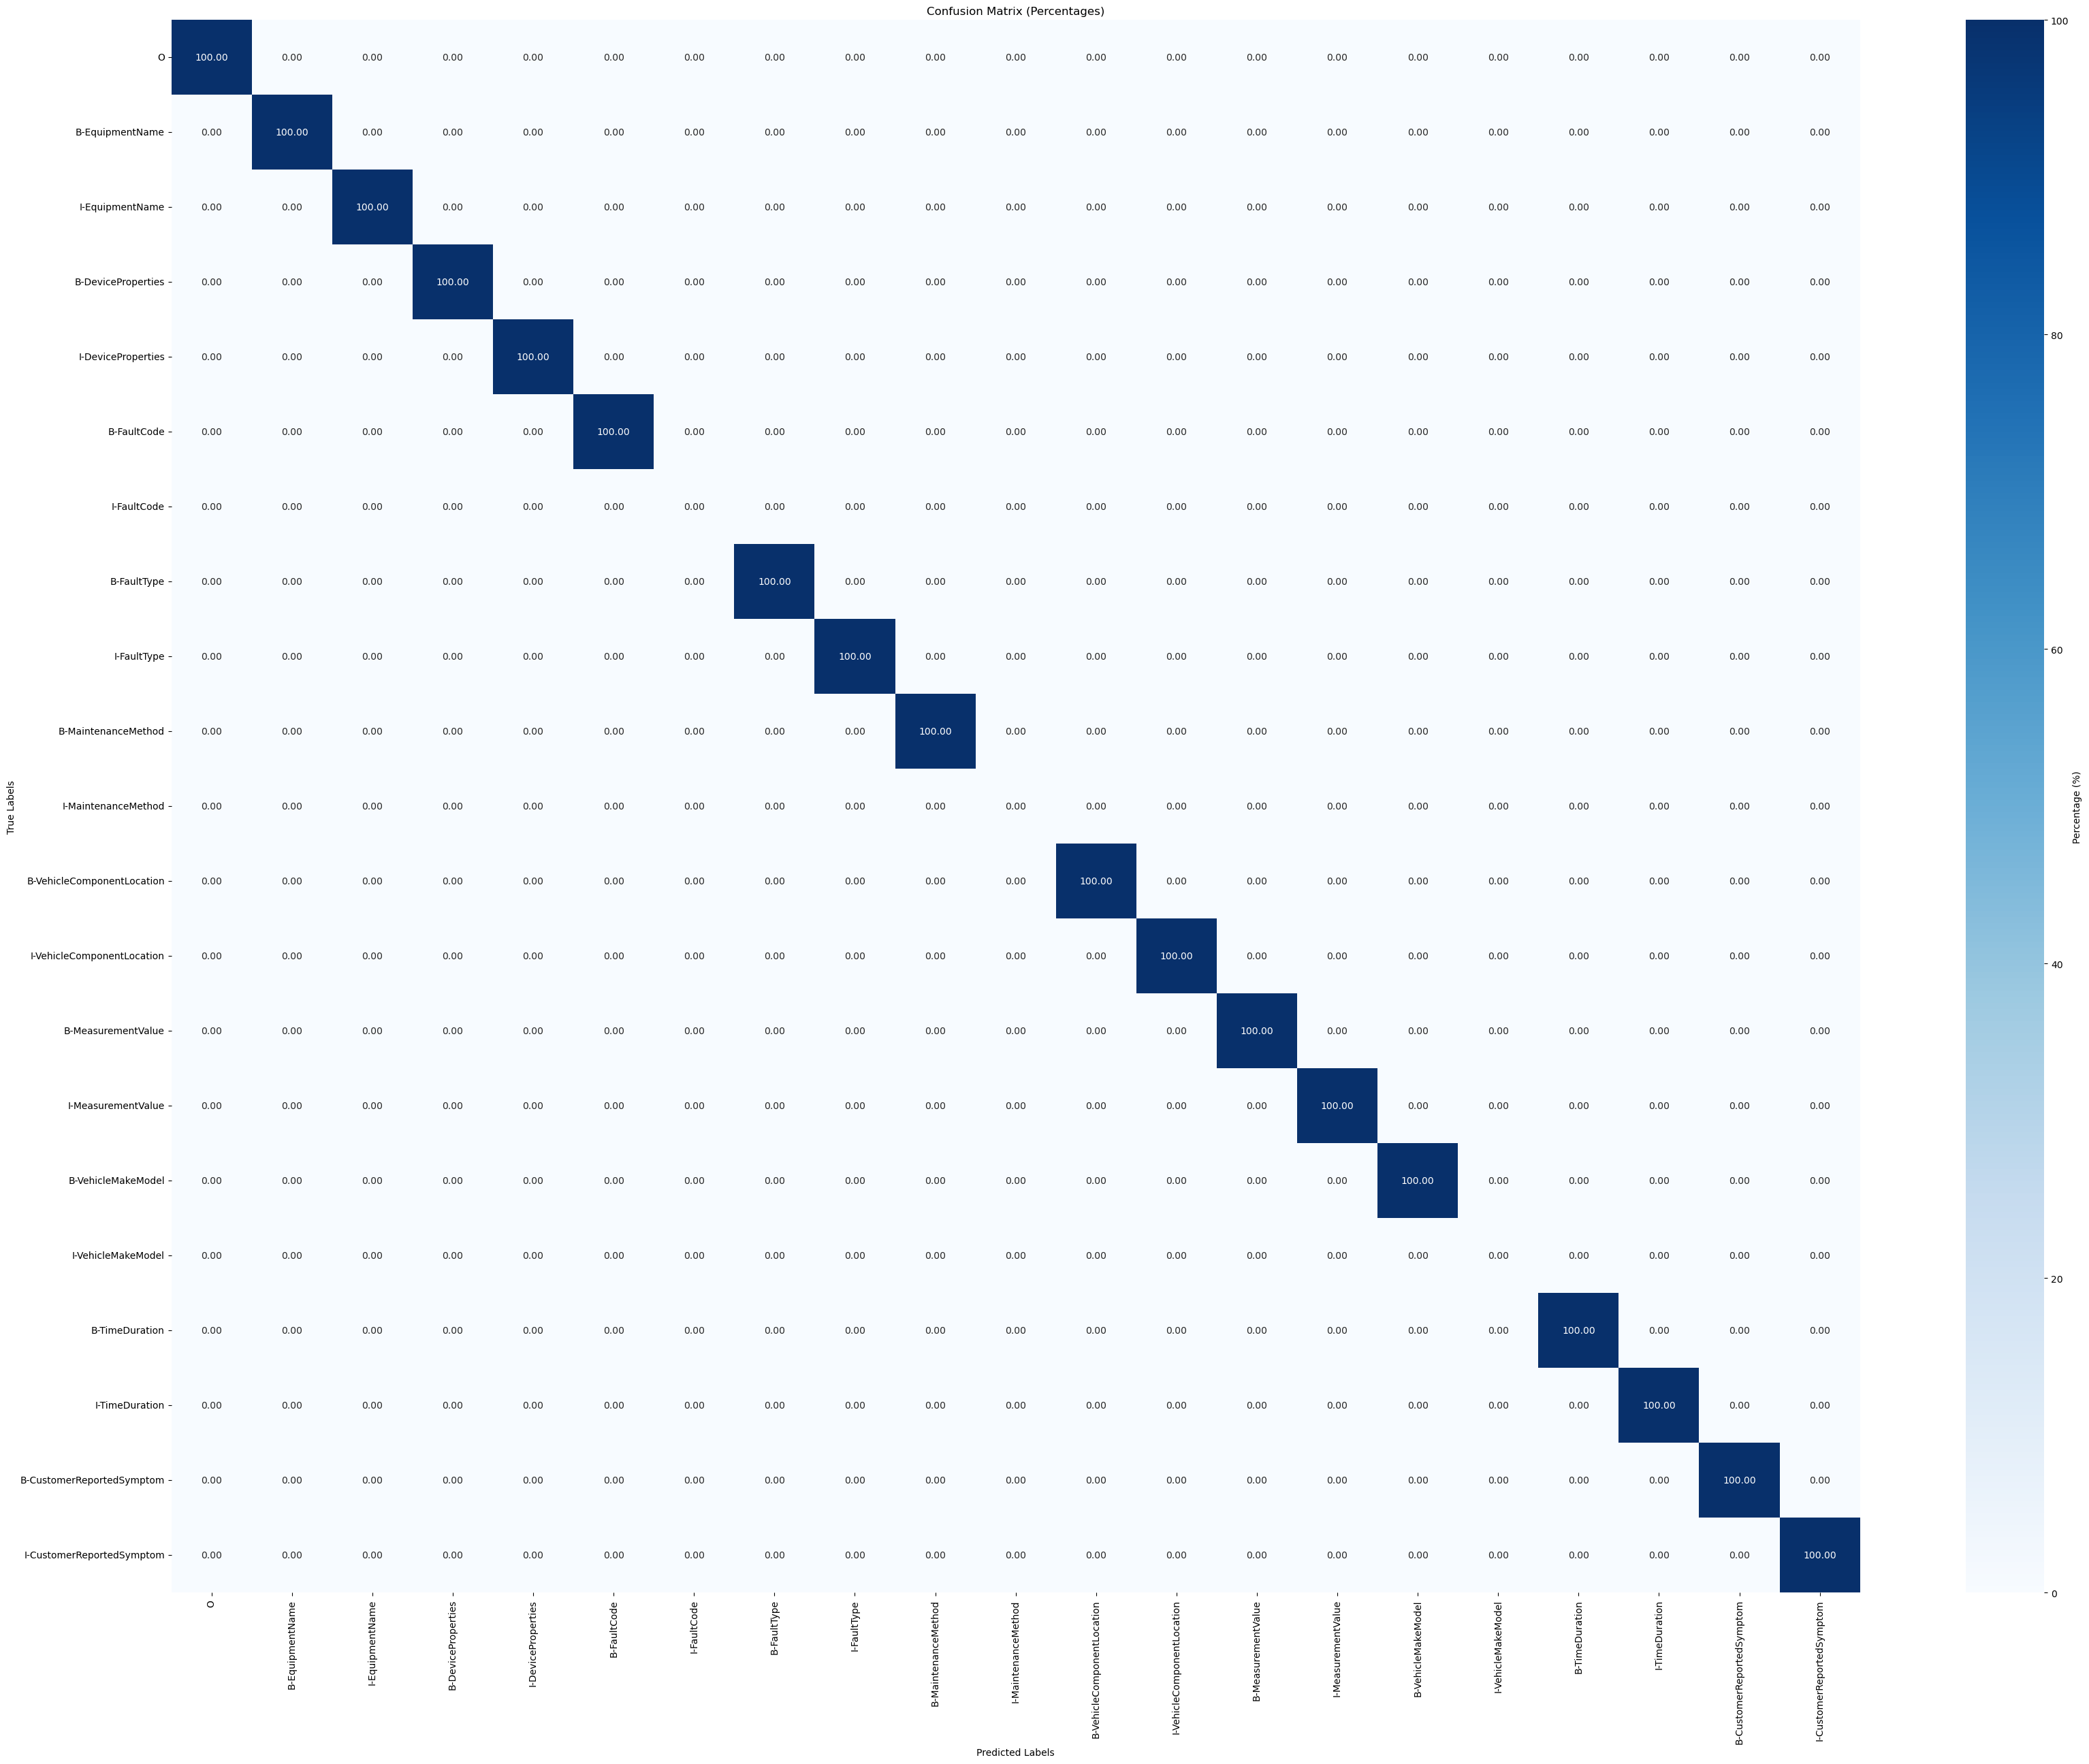

                          precision    recall  f1-score   support

 CustomerReportedSymptom       1.00      1.00      1.00      2000
        DeviceProperties       1.00      1.00      1.00      2000
           EquipmentName       1.00      1.00      1.00      1996
               FaultCode       1.00      1.00      1.00      2000
               FaultType       1.00      1.00      1.00      2000
       MaintenanceMethod       1.00      1.00      1.00      2000
        MeasurementValue       1.00      1.00      1.00      2000
            TimeDuration       1.00      1.00      1.00      2000
VehicleComponentLocation       1.00      1.00      1.00      2000
        VehicleMakeModel       1.00      1.00      1.00      2000

               micro avg       1.00      1.00      1.00     19996
               macro avg       1.00      1.00      1.00     19996
            weighted avg       1.00      1.00      1.00     19996

Entity Type          TP         FP         FN        
-------------------

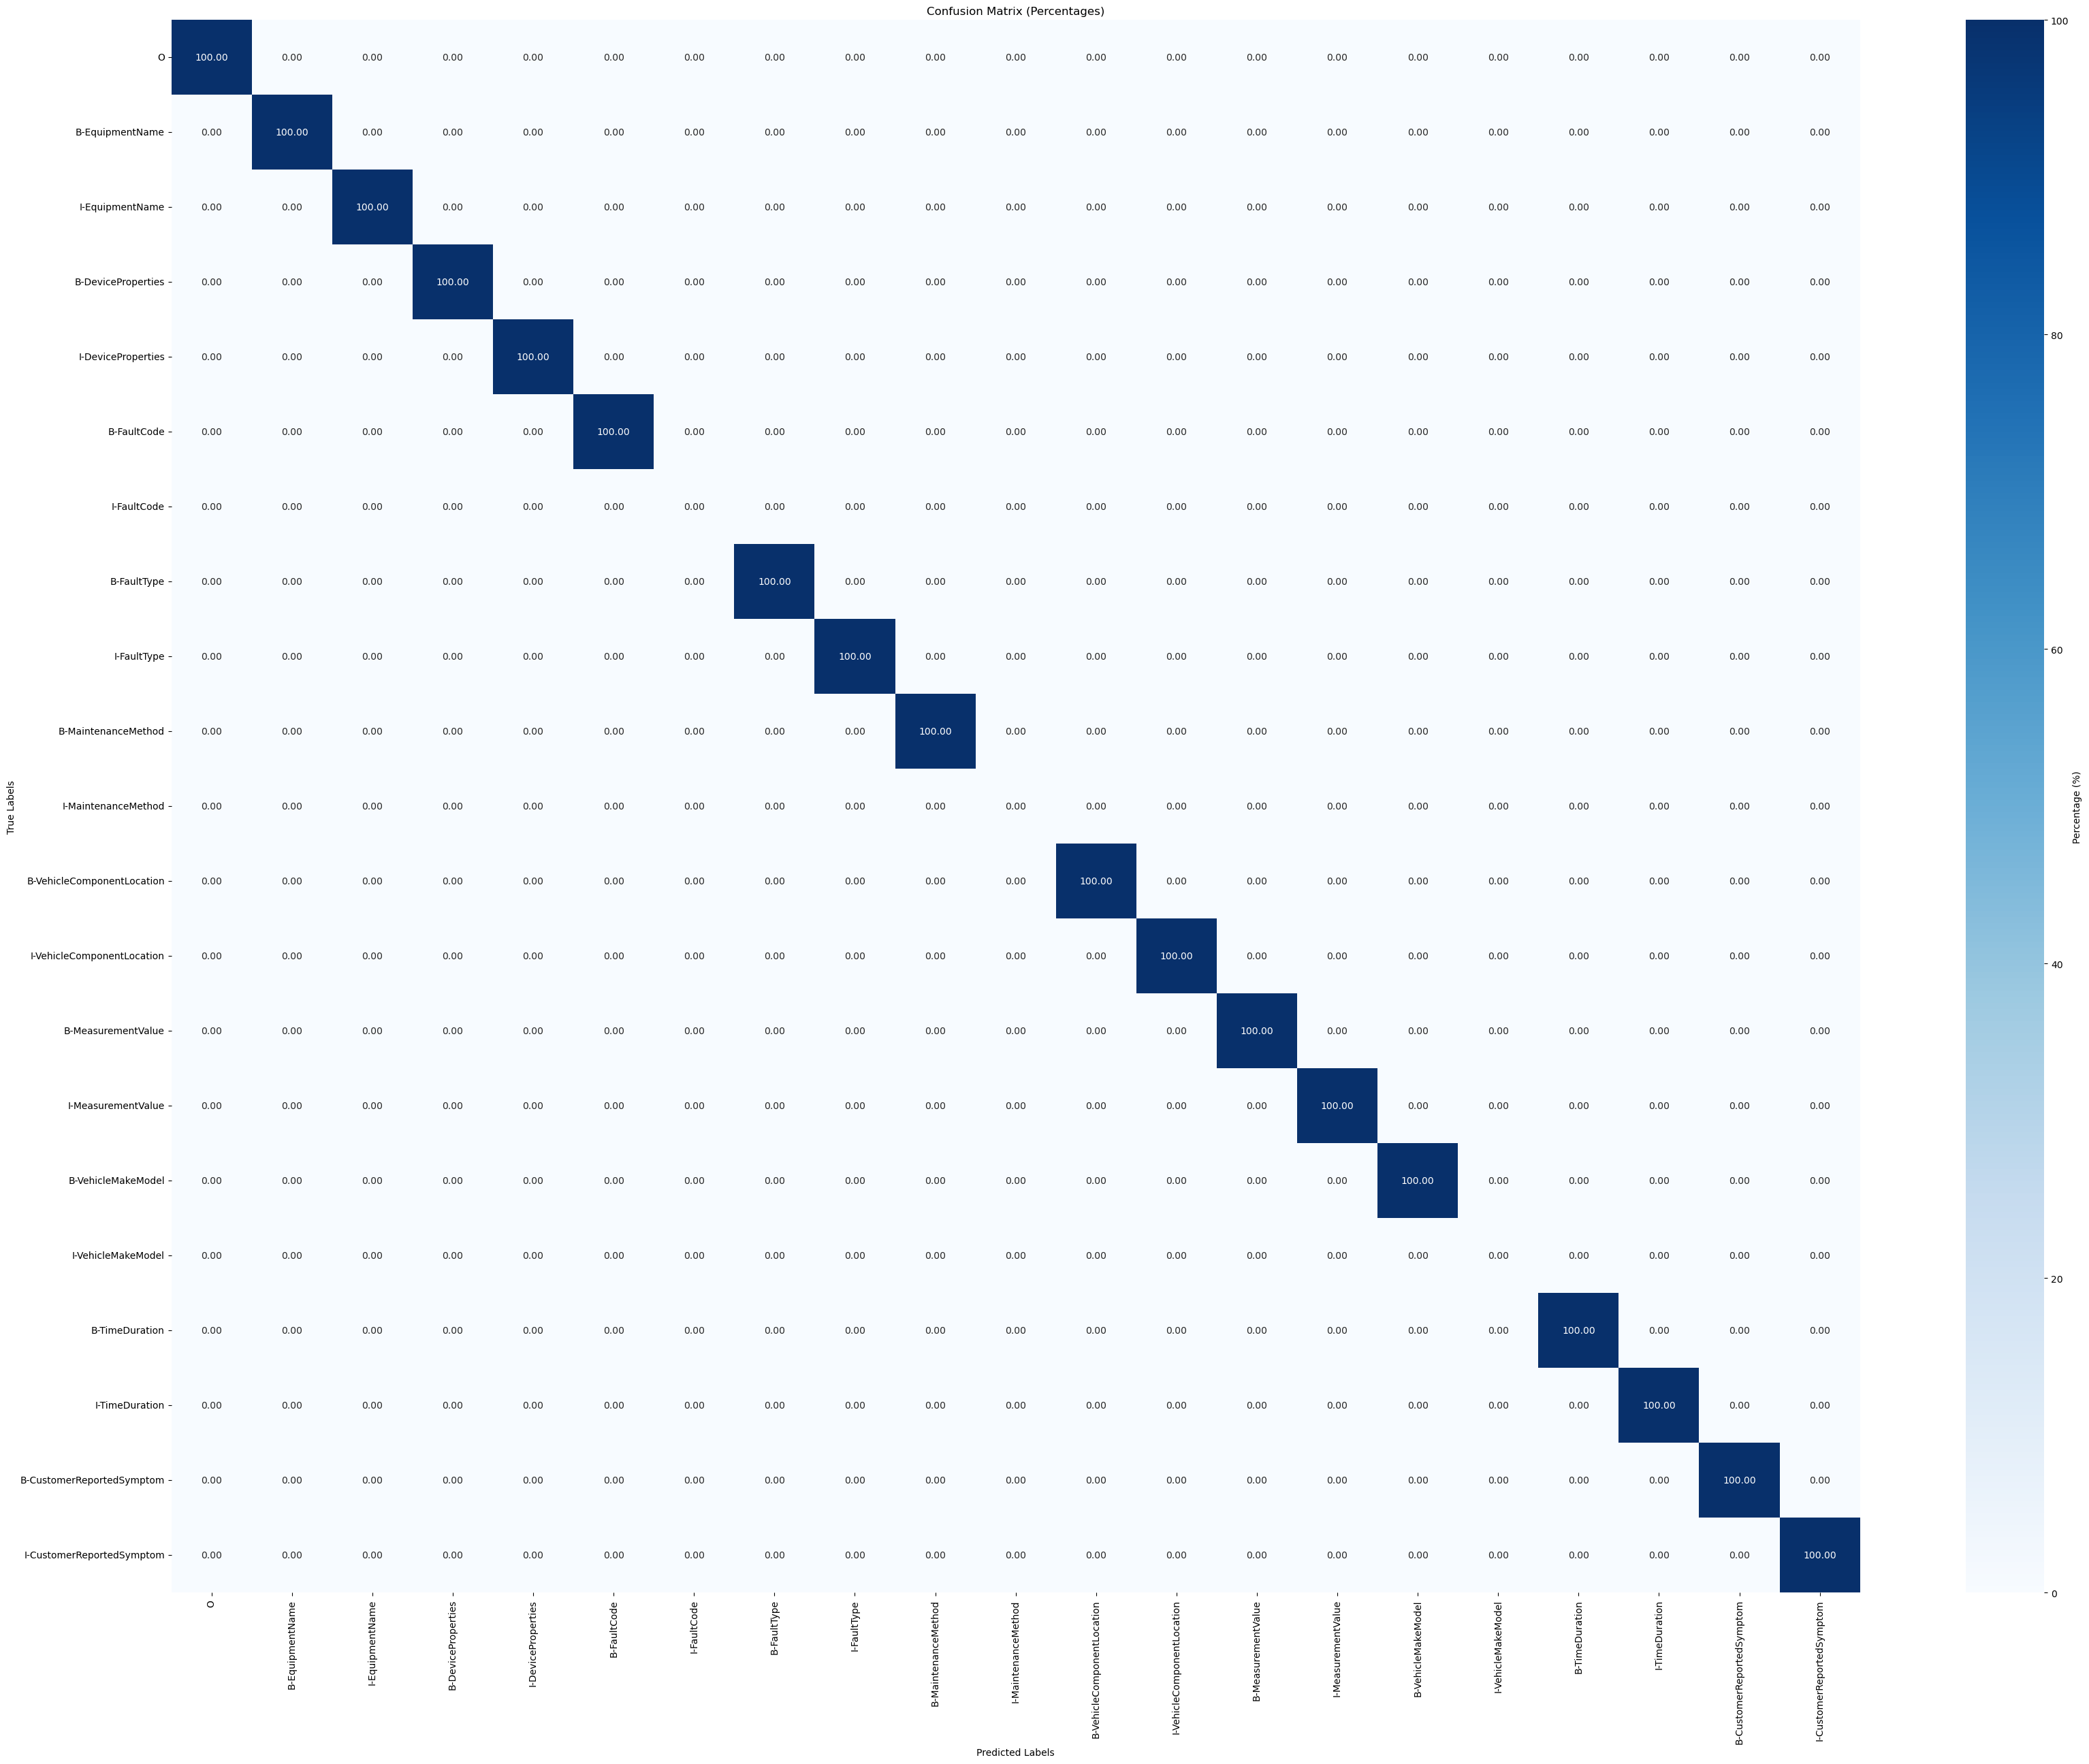

                          precision    recall  f1-score   support

 CustomerReportedSymptom       1.00      1.00      1.00      2000
        DeviceProperties       1.00      1.00      1.00      2000
           EquipmentName       1.00      1.00      1.00      1996
               FaultCode       1.00      1.00      1.00      2000
               FaultType       1.00      1.00      1.00      2000
       MaintenanceMethod       1.00      1.00      1.00      2000
        MeasurementValue       1.00      1.00      1.00      2000
            TimeDuration       1.00      1.00      1.00      2000
VehicleComponentLocation       1.00      1.00      1.00      2000
        VehicleMakeModel       1.00      1.00      1.00      2000

               micro avg       1.00      1.00      1.00     19996
               macro avg       1.00      1.00      1.00     19996
            weighted avg       1.00      1.00      1.00     19996

Entity Type          TP         FP         FN        
-------------------

In [66]:
training_args = TrainingArguments(
    output_dir=model_directory,
    learning_rate=2E-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    warmup_steps=50,
    adam_epsilon=1e-6,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    push_to_hub=False,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()
trainer.save_model(f"models/{model_name}")

In [56]:
from transformers import Trainer, TrainingArguments, AutoModelForTokenClassification, AutoTokenizer, DataCollatorForTokenClassification
from datasets import Dataset
from sklearn.metrics import classification_report
import numpy as np

# ------------------------------
# 1. Load Model & Tokenizer
# ------------------------------
model = AutoModelForTokenClassification.from_pretrained("models/pride_v1")
tokenizer = AutoTokenizer.from_pretrained("FacebookAI/roberta-base", add_prefix_space=True)

# Define your label mapping (must match the model's)
label_list = list(model.config.id2label.values())  # ['O', 'B-CustomerReportedSymptom', ...]
label2id = {label: i for i, label in enumerate(label_list)}
id2label = {i: label for label, i in label2id.items()}

# ------------------------------
# 2. Read CoNLL Dataset
# ------------------------------
def read_conll(filepath):
    sentences = []
    labels = []
    with open(filepath, 'r', encoding='utf-8') as f:
        tokens = []
        labs = []
        for line in f:
            if line.strip() == "" or line.startswith("-DOCSTART-"):
                if tokens:
                    sentences.append(tokens)
                    labels.append(labs)
                    tokens = []
                    labs = []
            else:
                splits = line.strip().split()
                tokens.append(splits[0])
                labs.append(splits[-1])
        if tokens:
            sentences.append(tokens)
            labels.append(labs)
    return {"tokens": sentences, "labels": labels}

dataset_dict = read_conll("goldset.conll")
hf_dataset = Dataset.from_dict(dataset_dict)

# ------------------------------
# 3. Tokenize & Align Labels
# ------------------------------
def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(
        examples["tokens"], 
        truncation=True, 
        is_split_into_words=True,
        max_length=512
    )

    labels = []
    for i, label in enumerate(examples["labels"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        label_ids = []
        previous_word_idx = None
        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)
            elif word_idx != previous_word_idx:
                label_ids.append(label2id[label[word_idx]])
            else:
                label_ids.append(label2id[label[word_idx]] if label[word_idx].startswith("I-") else -100)
            previous_word_idx = word_idx
        labels.append(label_ids)
    
    tokenized_inputs["labels"] = labels
    return tokenized_inputs

tokenized_dataset = hf_dataset.map(tokenize_and_align_labels, batched=True)

# ------------------------------
# 4. Data Collator
# ------------------------------
data_collator = DataCollatorForTokenClassification(tokenizer)

# ------------------------------
# 5. Define Metrics
# ------------------------------
def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    true_labels = [[id2label[l] for l in label if l != -100] for label in labels]
    true_preds = [
        [id2label[pred] for (pred, lab) in zip(pred, label) if lab != -100]
        for pred, label in zip(predictions, labels)
    ]

    # Flatten lists
    true_labels_flat = [l for sublist in true_labels for l in sublist]
    true_preds_flat = [p for sublist in true_preds for p in sublist]

    report = classification_report(true_labels_flat, true_preds_flat, zero_division=0, output_dict=True)
    return {"report": report}

# ------------------------------
# 6. Trainer & Evaluation
# ------------------------------
eval_args = TrainingArguments(
    output_dir="eval_results",
    per_device_eval_batch_size=16,
    do_train=False,
    do_eval=True,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=eval_args,
    data_collator=data_collator,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

# Evaluate
metrics = trainer.evaluate(tokenized_dataset)
print(metrics["eval_report"])


Map:   0%|          | 0/64 [00:00<?, ? examples/s]

/var/folders/hx/q1s4c6ws0dn84_dnnjvs7skc0000gp/T/ipykernel_94406/2602206676.py:112: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


{'B-CustomerReportedSymptom': {'precision': 0.11904761904761904, 'recall': 0.375, 'f1-score': 0.18072289156626506, 'support': 40.0}, 'B-DeviceProperties': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 36.0}, 'B-EquipmentName': {'precision': 0.23636363636363636, 'recall': 0.09774436090225563, 'f1-score': 0.13829787234042554, 'support': 133.0}, 'B-FaultCode': {'precision': 0.13392857142857142, 'recall': 0.8333333333333334, 'f1-score': 0.23076923076923078, 'support': 18.0}, 'B-FaultType': {'precision': 0.02027027027027027, 'recall': 0.13636363636363635, 'f1-score': 0.03529411764705882, 'support': 22.0}, 'B-MaintenanceMethod': {'precision': 0.23529411764705882, 'recall': 0.05714285714285714, 'f1-score': 0.09195402298850575, 'support': 70.0}, 'B-MeasurementValue': {'precision': 0.5833333333333334, 'recall': 0.7777777777777778, 'f1-score': 0.6666666666666666, 'support': 27.0}, 'B-TimeDuration': {'precision': 0.2, 'recall': 0.125, 'f1-score': 0.15384615384615385, 'support': 8.

In [62]:
from transformers import Trainer, TrainingArguments, AutoModelForTokenClassification, AutoTokenizer, DataCollatorForTokenClassification
from datasets import Dataset
from sklearn.metrics import classification_report
import numpy as np

# ------------------------------
# 1. Load Model & Tokenizer
# ------------------------------
model = AutoModelForTokenClassification.from_pretrained("models/pride_v1")
tokenizer = AutoTokenizer.from_pretrained("FacebookAI/roberta-base", add_prefix_space=True)

# Define label mapping
label_list = list(model.config.id2label.values())  # ['O', 'B-CustomerReportedSymptom', ...]
label2id = {label: i for i, label in enumerate(label_list)}
id2label = {i: label for label, i in label2id.items()}

# ------------------------------
# 2. Read CoNLL Dataset
# ------------------------------
def read_conll(filepath):
    sentences = []
    labels = []
    with open(filepath, 'r', encoding='utf-8') as f:
        tokens = []
        labs = []
        for line in f:
            if line.strip() == "" or line.startswith("-DOCSTART-"):
                if tokens:
                    sentences.append(tokens)
                    labels.append(labs)
                    tokens = []
                    labs = []
            else:
                splits = line.strip().split()
                tokens.append(splits[0])
                labs.append(splits[-1])
        if tokens:
            sentences.append(tokens)
            labels.append(labs)
    return {"tokens": sentences, "labels": labels}

dataset_dict = read_conll("advarsarial.conll")
hf_dataset = Dataset.from_dict(dataset_dict)

# ------------------------------
# 3. Tokenize & Align Labels
# ------------------------------
def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(
        examples["tokens"], 
        truncation=True, 
        is_split_into_words=True,
        max_length=512
    )

    labels = []
    for i, label in enumerate(examples["labels"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        label_ids = []
        previous_word_idx = None
        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)
            elif word_idx != previous_word_idx:
                label_ids.append(label2id[label[word_idx]])
            else:
                # For subwords, keep -100 unless it's 'I-'
                label_ids.append(label2id[label[word_idx]] if label[word_idx].startswith("I-") else -100)
            previous_word_idx = word_idx
        labels.append(label_ids)
    
    tokenized_inputs["labels"] = labels
    return tokenized_inputs

tokenized_dataset = hf_dataset.map(tokenize_and_align_labels, batched=True)

# ------------------------------
# 4. Data Collator
# ------------------------------
data_collator = DataCollatorForTokenClassification(tokenizer)

# ------------------------------
# 5. Define Metrics (combine B/I)
# ------------------------------
def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    def strip_bi(labels_list):
        # Remove 'B-' and 'I-' prefixes
        return [l[2:] if l != 'O' else l for l in labels_list]

    true_labels = [strip_bi([id2label[l] for l in label if l != -100]) for label in labels]
    true_preds = [
        strip_bi([id2label[pred] for (pred, lab) in zip(pred, label) if lab != -100])
        for pred, label in zip(predictions, labels)
    ]

    # Flatten lists
    true_labels_flat = [l for sublist in true_labels for l in sublist]
    true_preds_flat = [p for sublist in true_preds for p in sublist]

    report = classification_report(true_labels_flat, true_preds_flat, zero_division=0, output_dict=True)
    return {"report": report}

# ------------------------------
# 6. Trainer & Evaluation
# ------------------------------
eval_args = TrainingArguments(
    output_dir="eval_results",
    per_device_eval_batch_size=16,
    do_train=False,
    do_eval=True,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=eval_args,
    data_collator=data_collator,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

# Evaluate
metrics = trainer.evaluate(tokenized_dataset)
print(metrics["eval_report"])


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

/var/folders/hx/q1s4c6ws0dn84_dnnjvs7skc0000gp/T/ipykernel_94406/2168174098.py:117: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


{'CustomerReportedSymptom': {'precision': 0.16569175991861648, 'recall': 0.9977029096477795, 'f1-score': 0.28418756815703383, 'support': 1306.0}, 'DeviceProperties': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 500.0}, 'EquipmentName': {'precision': 0.07417433676231727, 'recall': 0.24684684684684685, 'f1-score': 0.11407160699417153, 'support': 555.0}, 'FaultCode': {'precision': 0.49002849002849, 'recall': 0.9856733524355301, 'f1-score': 0.6546146527117032, 'support': 349.0}, 'FaultType': {'precision': 0.03288672350791717, 'recall': 0.02906350914962325, 'f1-score': 0.030857142857142857, 'support': 929.0}, 'MaintenanceMethod': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 549.0}, 'MeasurementValue': {'precision': 0.7454545454545455, 'recall': 1.0, 'f1-score': 0.8541666666666666, 'support': 451.0}, 'O': {'precision': 0.99870814942405, 'recall': 0.5999482635969734, 'f1-score': 0.7495959922430511, 'support': 15463.0}, 'TimeDuration': {'precision': 0.85497470

In [64]:
from tabulate import tabulate

# ------------------------------
# Pretty Print Classification Report (including averages)
# ------------------------------
# Pretty print classification report in aligned text format
def print_classification_report_text(report_dict):
    header = f"{'Entity':35} {'Precision':>9} {'Recall':>7} {'F1-Score':>9} {'Support':>8}"
    print(header)
    print("-" * len(header))
    
    for label, metrics in report_dict.items():
        if isinstance(metrics, dict):
            print(f"{label:35} "
                  f"{metrics.get('precision', 0):9.2f} "
                  f"{metrics.get('recall', 0):7.2f} "
                  f"{metrics.get('f1-score', 0):9.2f} "
                  f"{int(metrics.get('support', 0)):8}")

# Example usage
metrics = trainer.evaluate(tokenized_dataset)
report = metrics["eval_report"]
#For demonstration, assuming report is a dict from classification_report
print_classification_report_full(report)


+--------------------------+-------------+----------+------------+-----------+
| Entity                   |   Precision |   Recall |   F1-Score |   Support |
+==========================+=============+==========+============+===========+
| CustomerReportedSymptom  |       0.166 |    0.998 |      0.284 |      1306 |
+--------------------------+-------------+----------+------------+-----------+
| DeviceProperties         |       0     |    0     |      0     |       500 |
+--------------------------+-------------+----------+------------+-----------+
| EquipmentName            |       0.074 |    0.247 |      0.114 |       555 |
+--------------------------+-------------+----------+------------+-----------+
| FaultCode                |       0.49  |    0.986 |      0.655 |       349 |
+--------------------------+-------------+----------+------------+-----------+
| FaultType                |       0.033 |    0.029 |      0.031 |       929 |
+--------------------------+-------------+----------